## MODELO  - CARTERA

In [1]:
# Instalacion de paquetes base del notebook
%pip install -q awswrangler==3.13.0 jupyterlab_execute_time seaborn scikit-learn scorecardpy boto3

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
# EBM
%pip install -q interpret

Note: you may need to restart the kernel to use updated packages.


In [4]:
# LogReg + WOE
%pip install -q optbinning

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install -q xgboost==2.1.3

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install -q lightgbm

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install -q joblib

Note: you may need to restart the kernel to use updated packages.


In [9]:
# ==============================================================================
# CONFIGURACION Y LIBRERIAS  (celda unica de imports y setup)
# ==============================================================================

# --- Nativos ---
from dateutil.relativedelta import relativedelta
from time import gmtime, strftime
from datetime import datetime
import random as rn
import joblib
import time
import json
import sys
import os
import gc

# --- Nube ---
import awswrangler as wr
import boto3

# --- Calculo ---
import pandas as pd
import numpy as np
import scipy
from scipy.stats import chi2_contingency

# --- Grafico ---
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

# --- ML: preprocessing ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# --- ML: modelos ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# LightGBM
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping, log_evaluation

# XGBoost
import xgboost as xgb

# Optuna (instala si falta)
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    import subprocess
    print("Optuna no disponible. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True

# Scorecard
import scorecardpy as sc

# --- Configuracion de display ---
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# --- Paths del proyecto (agrega carpeta padre y abuela al sys.path) ---
for _p in (os.path.dirname(os.getcwd()), os.path.dirname(os.path.dirname(os.getcwd()))):
    if _p not in sys.path:
        sys.path.append(_p)
BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
print("BASE_DIR:::", BASE_DIR)

# Helpers de feature selection
from feature_selection_v1 import *

# ------------------------------------------------------------------
# SEMILLA UNICA DE REPRODUCIBILIDAD (fuente de verdad para todo el notebook)
# ------------------------------------------------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
rn.seed(SEED)

# --- Configuracion VPC ---
esquema_vpc = 'disc_comercial'
path_ = 's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/'


BASE_DIR::: c:\Users\b46417\OneDrive - Interbank


In [10]:
import pandas as pd
import numpy as np
from utils_modelo import (
    validar_datasets,
    analizar_variables,
    calcular_vif,
    optimizar_modelos,
    evaluar_modelos,
    comparar_modelos,
    obtener_importancia,
    analisis_deciles,
    escalera_propension,
analisis_deciles_por_mes,
    plot_optimization_history,
    plot_roc_curves,
    plot_feature_importance
)


In [11]:
# Hiperparametros de busqueda de Optuna
N_TRIALS_OPTUNA = 120

# Re-sembrar justo antes del modelado (SEED definido en la celda de configuracion)
np.random.seed(SEED)
rn.seed(SEED)
print(f"SEED={SEED} | N_TRIALS_OPTUNA={N_TRIALS_OPTUNA}")


SEED=42 | N_TRIALS_OPTUNA=120


In [12]:
# ============================================================================
# PASO 0: CARGAR DATOS
# ============================================================================
print("\n" + "="*100)
print(" PASO 0: CARGA DE DATOS")
print("="*100)

# Cargar datos
train_final = pd.read_csv('final_train.csv')
valid_final = pd.read_csv('final_valid.csv')
test_final = pd.read_csv('final_test.csv')

print(f"Train: {train_final.shape}")
print(f"Valid: {valid_final.shape}")
print(f"Test:  {test_final.shape}")




 PASO 0: CARGA DE DATOS
Train: (56881, 1335)
Valid: (21790, 1335)
Test:  (20061, 1335)


In [13]:
train_final.info(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56881 entries, 0 to 56880
Data columns (total 1335 columns):
 #     Column                                                         Dtype  
---    ------                                                         -----  
 0     periodo_campania                                               int64  
 1     num_ruc                                                        object 
 2     y_2m                                                           int64  
 3     y_3m                                                           int64  
 4     saldo_total                                                    float64
 5     n_creditos                                                     int64  
 6     monto_desem_total                                              float64
 7     pct_saldo_remanente                                            float64
 8     tea_principal                                                  float64
 9     meses_desde_desem_min   

In [14]:
# Variables del modelo (AJUSTAR SEGUN TU MODELO)

variables_finales = [
    'sow_ibk_promedio_12m',                              # 1
    'frecuencia_colocaciones_pct_6m',                    # 2
    'sow_ibk_meses_mayor_50_pct',                        # 3
    'sow_ibk_promedio_6m',                               # 4
    'atraso_max',                                        # 5
    'max_atraso_competencia_coloc_directas_ajustado',   # 6
    'scoring_min',                                       # 7
    'd_n_creditos_3m',                                   # 8
    'var_abs_pasivo_6m',                                 # 9
    'var_pct_pasivo_6m',                                 # 10
    'min_saldo_pasivo_12m',                              # 11
    'promedio_movil_pasivo_3m',                          # 12
    'frecuencia_pasivo_pct_6m',                          # 13
    'deuda_noibk_promedio_12m',                          # 14
    'var_ibk_directa_m12_amt',                           # 15
    'bcp_directa_m12_amt',                               # 16
    'bancos_ytd_amt',                                    # 17
    'avg_nro_entidades_bancos_u12m',                     # 18
    'avg_nro_reg_coloc_directas_bancos_ajustado_u6m',   # 19
    'cant_empresas_max_12m',                             # 20
    'tendencia_saldo_ibk_coloc_directas_amt_general',    # 21
    'avg_saldo_bco_no_ibk_garantias_amt_u12m',           # 22
    'cuotas_total_cap_trabajo',                          # 23
    'pct_avance_cuotas_cap_trabajo',                     # 24
    'tea_cap_trabajo',                                   # 25
    'meses_desde_desem_cap_trabajo',                     # 26
    'meses_gestionados_ult12m',      
   
    'avg_saldo_competencia_coloc_directas_general_vig_amt_u12m',  # estab 4/4
    'avg_saldo_bco_no_ibk_coloc_directas_vig_amt_u12m',           # 3/4
    'avg_saldo_bco_garantias_hipo_amt_u12m',                      # 3/4
    'monto_oferta_max_ult6m',                                     # 3/4
    'tasa_max_ult3m',                                             # 3/4
    'max_atraso_coloc_directas_general_u6m'                    # 3/4


]

target = 'y_3m'

print(f"\n Variables en el modelo: {len(variables_finales)}")


 Variables en el modelo: 33


In [15]:
# ============================================================================
# PASO 1: VALIDACIÓN DE NULOS
# ============================================================================

validar_datasets(train_final, valid_final, test_final, variables_finales)



 VALIDACIÓN DE NULOS
✓ train_final: Sin nulos en variables del modelo
✓ valid_final: Sin nulos en variables del modelo
✓ test_final: Sin nulos en variables del modelo

✓ Validación de nulos completada. Todos los datasets están limpios.


True

In [16]:
# ============================================================================
# PASO 2: PREPARAR X e y (SIN NORMALIZACIÓN)
# ============================================================================
print("\n" + "="*100)
print(" PASO 2: PREPARACIÓN DE X e y (DATOS CRUDOS - SIN NORMALIZACIÓN)")
print("="*100)

X_train = train_final[variables_finales].copy()
y_train = train_final[target].copy()

X_valid = valid_final[variables_finales].copy()
y_valid = valid_final[target].copy()

X_test = test_final[variables_finales].copy()
y_test = test_final[target].copy()

print(" Dimensiones:")
print(f"   X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   X_valid: {X_valid.shape} | y_valid: {y_valid.shape}")
print(f"   X_test:  {X_test.shape} | y_test:  {y_test.shape}")

print(f"\n Distribución del target:")
print(f"   Train: {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"   Valid: {y_valid.value_counts(normalize=True).round(4).to_dict()}")
print(f"   Test:  {y_test.value_counts(normalize=True).round(4).to_dict()}")


 PASO 2: PREPARACIÓN DE X e y (DATOS CRUDOS - SIN NORMALIZACIÓN)
 Dimensiones:
   X_train: (56881, 33) | y_train: (56881,)
   X_valid: (21790, 33) | y_valid: (21790,)
   X_test:  (20061, 33) | y_test:  (20061,)

 Distribución del target:
   Train: {0: 0.9846, 1: 0.0154}
   Valid: {0: 0.9779, 1: 0.0221}
   Test:  {0: 0.9768, 1: 0.0232}


In [17]:
# ============================================================================
# PASO 3: ANÁLISIS ESTADÍSTICO DE VARIABLES
# ============================================================================

analisis_vars = analizar_variables(X_train)

# ============================================================================
# PASO 4: ANÁLISIS DE MULTICOLINEALIDAD (VIF)
# ============================================================================

vif_data = calcular_vif(X_train, variables_finales)




 ANÁLISIS ESTADÍSTICO DE VARIABLES
Analizando distribución de variables en TRAIN...

Resumen estadístico:

                                                                        media                 std    skewness %outliers es_binaria
variable                                                                                                                          
sow_ibk_promedio_12m                                                  54.8632            36.32797   -0.054357       0.0      False
frecuencia_colocaciones_pct_6m                                      86.408478           28.508373   -1.984437       0.0      False
sow_ibk_meses_mayor_50_pct                                           5.945289            4.863383   -0.001734       0.0      False
sow_ibk_promedio_6m                                                 60.476919           36.090876   -0.288787       0.0      False
atraso_max                                                           4.696964            9.107523     6.57


 HYPERPARAMETER TUNING CON OPTUNA - GINI VALID PENALIZADO POR BRECHA

 Scale pos weight: 63.86
 Penalizacion de brecha (gap_penalty): 1.0  -> objetivo = gini_valid - 1.0*max(0, gini_train - gini_valid)

 OPTUNA: Optimizando LightGBM
Ejecutando 120 trials...


  0%|          | 0/120 [00:00<?, ?it/s]


✓ Mejor Gini: 0.3594
 Mejores parámetros:
   • n_estimators: 2705
   • num_leaves: 43
   • max_depth: 3
   • learning_rate: 0.0594043024340775
   • subsample: 0.5864334099789271
   • subsample_freq: 6
   • colsample_bytree: 0.43540017870239106
   • feature_fraction_bynode: 0.6218463422375321
   • min_child_samples: 458
   • min_child_weight: 2.0025249278884374
   • reg_alpha: 0.04217266414398615
   • reg_lambda: 0.8311694061998511
   • min_gain_to_split: 0.3640672786280103
   • path_smooth: 3.624252205156564
   • max_bin: 147
   • extra_trees: False
   • is_unbalance: True

 OPTUNA: Optimizando XGBoost
Ejecutando 120 trials...


  0%|          | 0/120 [00:00<?, ?it/s]


✓ Mejor objetivo (gini valid penalizado): 0.3199
 Mejores parámetros:
   • max_depth: 2
   • max_leaves: 105
   • min_child_weight: 219
   • grow_policy: lossguide
   • learning_rate: 0.005433322548329642
   • subsample: 0.8453018500804849
   • colsample_bytree: 0.47226534215999694
   • colsample_bylevel: 0.7987825617329964
   • colsample_bynode: 0.8391152564964521
   • reg_alpha: 0.0031433760811402705
   • reg_lambda: 7.193357464502576
   • gamma: 0.6853351858877058
   • max_delta_step: 9
   • scale_pos_weight: 90.11098312775214
   • max_bin: 261
   • n_estimators (best_iteration): 5

 RESUMEN DE HYPERPARAMETER TUNING

 Ranking por objetivo penalizado (gini valid - gap):

  Modelo  Best_Obj_Valid  N_Trials
LightGBM        0.359362       120
 XGBoost        0.319869       120


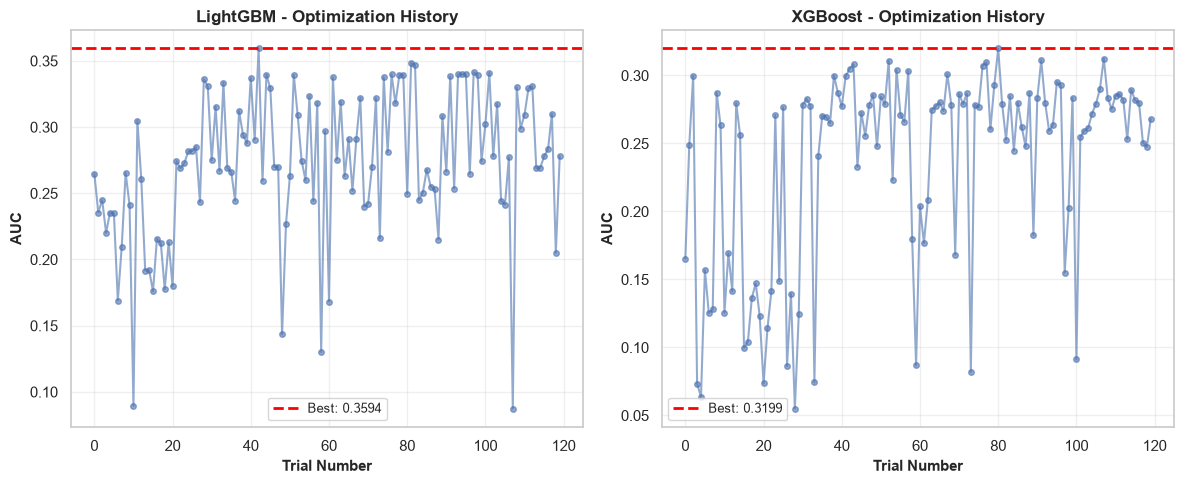

 Historia de optimización mostrada


In [18]:
# ============================================================================
# PASO 5: HYPERPARAMETER TUNING CON OPTUNA
# ============================================================================

resultados_optuna = optimizar_modelos(
    X_train, y_train, 
    X_valid, y_valid,
    n_trials=N_TRIALS_OPTUNA,
    SEED=SEED
)

# Visualizar historia de optimización
plot_optimization_history(resultados_optuna['studies'])



In [19]:
# ============================================================================
# PASO 6: EVALUACIÓN DE MODELOS
# ============================================================================

resultados, modelos_entrenados = evaluar_modelos(
    resultados_optuna['modelos'],
    X_train, y_train,
    X_valid, y_valid,
    X_test, y_test
)



 EVALUACIÓN DE MODELOS

 Evaluando: LightGBM (Optuna)

 Resultados:
   AUC   → Train: 0.7355 | Valid: 0.7076 | Test: 0.6678
   Gini  → Train: 0.4711 | Valid: 0.4152 | Test: 0.3357
   KS    → Train: 0.3980 | Valid: 0.3523 | Test: 0.2851

 Evaluando: XGBoost (Optuna)

 Resultados:
   AUC   → Train: 0.7393 | Valid: 0.6967 | Test: 0.6649
   Gini  → Train: 0.4785 | Valid: 0.3934 | Test: 0.3298
   KS    → Train: 0.4048 | Valid: 0.3725 | Test: 0.3036


In [20]:
# ============================================================================
# PASO 7: COMPARACIÓN Y SELECCIÓN DEL MEJOR MODELO
# ============================================================================

df_comparacion, mejor_modelo_nombre = comparar_modelos(resultados)

mejor_modelo = modelos_entrenados[mejor_modelo_nombre]


 COMPARACIÓN DE MODELOS

 Ranking de Modelos (por AUC Test):

                   AUC_train  AUC_valid  AUC_test  Gini_test  KS_valid  Overfit
LightGBM (Optuna)     0.7355     0.7076    0.6678     0.3357    0.3523   0.0279
XGBoost (Optuna)      0.7393     0.6967    0.6649     0.3298    0.3725   0.0426

✓ Mejor modelo (auto por AUC test): LightGBM (Optuna)
   AUC Test: 0.6678


In [21]:
# Modelo elegido para TODOS los cálculos posteriores
mejor_modelo_nombre = 'XGBoost (Optuna)'
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]
print(f"✓ Modelo elegido: {mejor_modelo_nombre} -> {type(mejor_modelo).__name__}")


✓ Modelo elegido: XGBoost (Optuna) -> XGBClassifier


In [22]:
from utils_significancia_3 import analisis_completo_significancia

# Ejecutar análisis completo
resultados_var = analisis_completo_significancia(
    modelo=mejor_modelo,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test
)

# Variables confirmadas por TODOS los métodos
vars_confirmadas = resultados_var['consolidado']['vars_en_todos']
print(f"\n Variables altamente significativas: {vars_confirmadas}")


 ANÁLISIS COMPLETO DE SIGNIFICANCIA DE VARIABLES

────────────────────────────────────────────────────────────────────────────────────────────────────
 MÉTODO 1: PERMUTATION IMPORTANCE
────────────────────────────────────────────────────────────────────────────────────────────────────

 PERMUTATION IMPORTANCE

 Calculando permutation importance (10 repeticiones por variable)...
   Baseline AUC: 0.696691
   Procesando variable 10/33...
   Procesando variable 20/33...
   Procesando variable 30/33...

✓ Variables significativas (caída AUC >= 0.0010): 7

Variable                                           AUC Drop (mean)        Std
─────────────────────────────────────────────────────────────────────────────
 cuotas_total_cap_trabajo                                0.062542   0.006597
 sow_ibk_promedio_12m                                    0.005775   0.002483
 frecuencia_colocaciones_pct_6m                          0.004680   0.002842
 pct_avance_cuotas_cap_trabajo                         


 PASO 8: IMPORTANCIA DE VARIABLES

 Top 15 Variables más importantes (XGBoost (Optuna)):

                                                 variable  importance  importance_pct  cumulative_pct
                           frecuencia_colocaciones_pct_6m    0.255224       25.520000       25.520000
                                 cuotas_total_cap_trabajo    0.203830       20.379999       45.900002
                            pct_avance_cuotas_cap_trabajo    0.162740       16.270000       62.169998
                                     sow_ibk_promedio_12m    0.157995       15.800000       77.970001
avg_saldo_competencia_coloc_directas_general_vig_amt_u12m    0.086377        8.640000       86.610001
                                 deuda_noibk_promedio_12m    0.082356        8.240000       94.849998
                            meses_desde_desem_cap_trabajo    0.031086        3.110000       97.959999
                                          tea_cap_trabajo    0.012133        1.210000       9

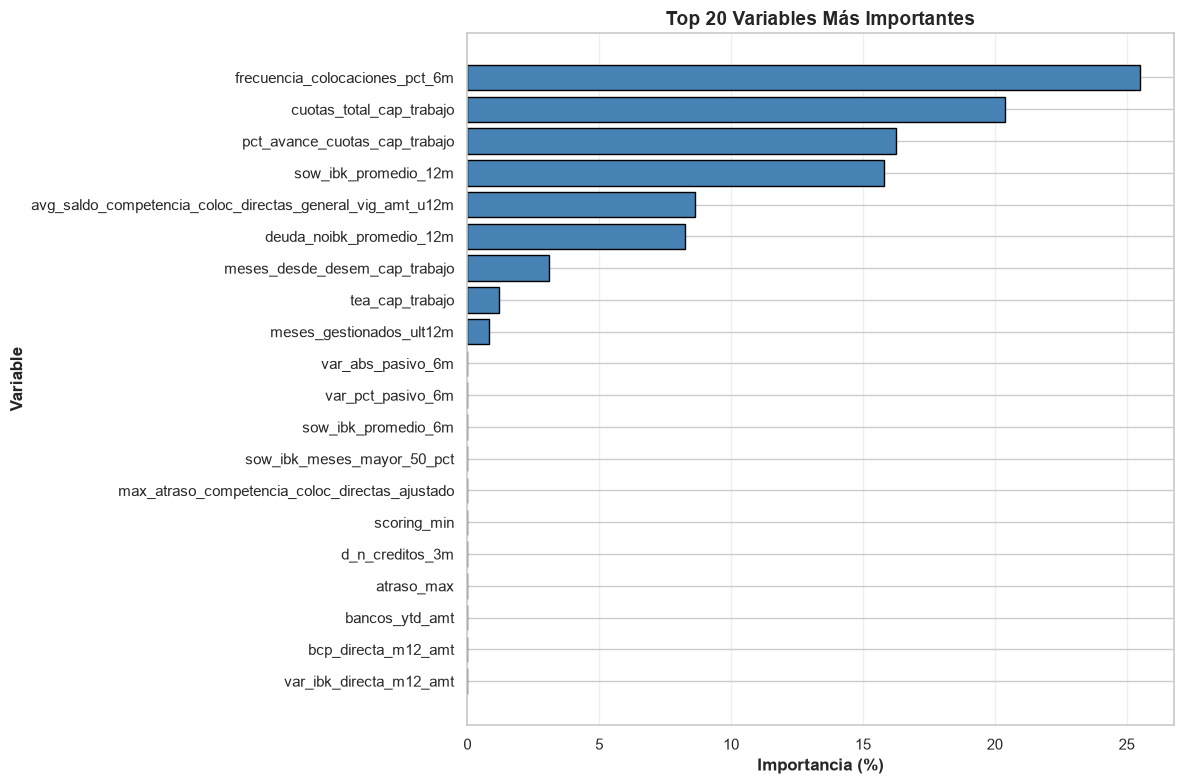

In [23]:
# ============================================================================
# PASO 8: IMPORTANCIA DE VARIABLES
# ============================================================================
print("\n" + "="*100)
print(" PASO 8: IMPORTANCIA DE VARIABLES")
print("="*100)

df_importance = obtener_importancia(mejor_modelo, X_train, mejor_modelo_nombre)

if df_importance is not None:
    print(f"\n Top 15 Variables más importantes ({mejor_modelo_nombre}):\n")
    print(df_importance.head(15).to_string(index=False))
    
    # Visualizar
    plot_feature_importance(df_importance, top_n=20)

In [24]:
df_importance

,variable,importance,importance_pct,cumulative_pct
0,frecuencia_colocaciones_pct_6m,0.255224,25.520000,25.520000
1,cuotas_total_cap_trabajo,0.203830,20.379999,45.900002
2,pct_avance_cuotas_cap_trabajo,0.162740,16.270000,62.169998
3,sow_ibk_promedio_12m,0.157995,15.800000,77.970001
4,avg_saldo_competencia_coloc_directas_general_v...,0.086377,8.640000,86.610001
5,deuda_noibk_promedio_12m,0.082356,8.240000,94.849998
6,meses_desde_desem_cap_trabajo,0.031086,3.110000,97.959999
7,tea_cap_trabajo,0.012133,1.210000,99.169998
8,meses_gestionados_ult12m,0.008259,0.830000,100.000000
9,var_abs_pasivo_6m,0.000000,0.000000,100.000000



 PASO 9: CURVAS ROC


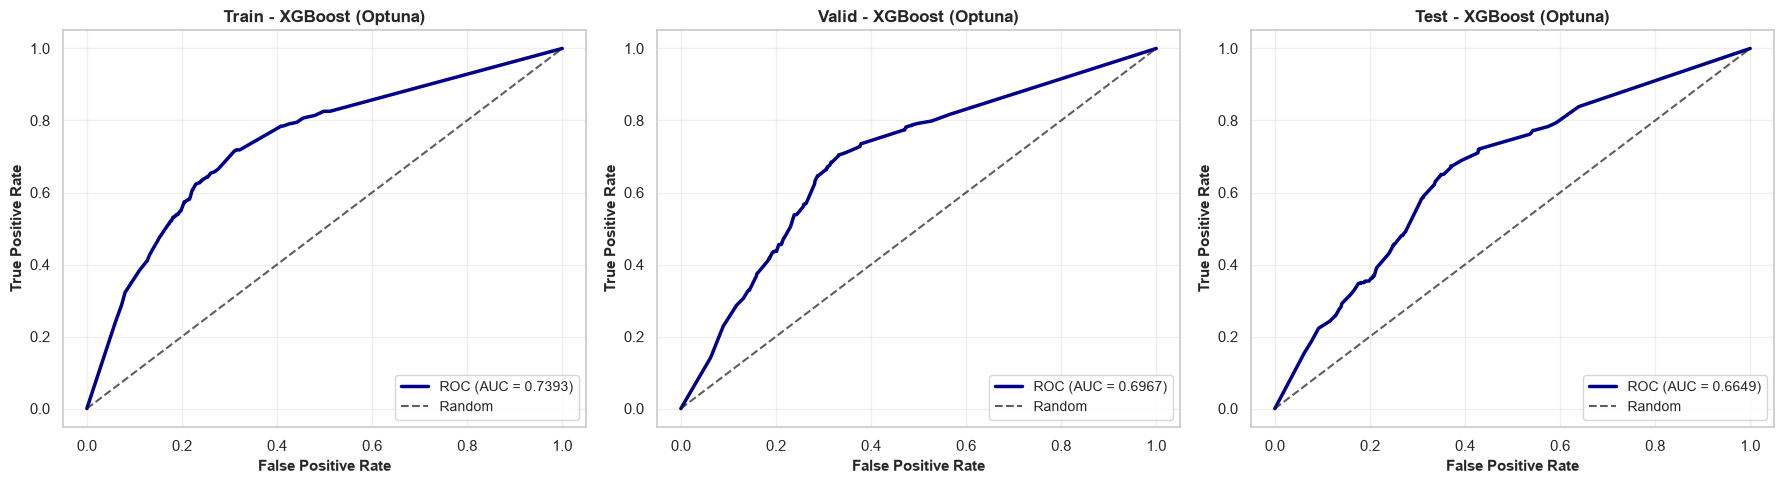

In [25]:
# ============================================================================
# PASO 9: CURVAS ROC
# ============================================================================
print("\n" + "="*100)
print(" PASO 9: CURVAS ROC")
print("="*100)

plot_roc_curves(
    y_train, y_valid, y_test,
    resultados[mejor_modelo_nombre]['predicciones_train'],
    resultados[mejor_modelo_nombre]['predicciones_valid'],
    resultados[mejor_modelo_nombre]['predicciones_test'],
    mejor_modelo_nombre
)


In [26]:
# ============================================================================
# PASO 10: ANÁLISIS DE DECILES
# ============================================================================
print("\n" + "="*100)
print(" PASO 10: ANÁLISIS DE DECILES")
print("="*100)

df_deciles_test = analisis_deciles(
    y_test, 
    resultados[mejor_modelo_nombre]['predicciones_test'],
    'Test'
)


 PASO 10: ANÁLISIS DE DECILES


ValueError: Bin labels must be one fewer than the number of bin edges

In [ ]:
### >>> PREDICCION
pd.Series(resultados[mejor_modelo_nombre]['predicciones_test']).hist()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)
pd.options.mode.chained_assignment = None

# ============================================================================
# COLORES INTERBANK
# ============================================================================
def rgb_to_mpl(rgb_str):
    nums = rgb_str.replace('rgb(', '').replace(')', '').split(',')
    return tuple([int(n)/255 for n in nums])

COLOR_VERDE_IBK = rgb_to_mpl('rgb(0,208,60)')
COLOR_AZUL_IBK = rgb_to_mpl('rgb(31,69,146)')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Poppins', 'Arial', 'Helvetica']

# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================
def format_number(val, is_amount=False):
    if pd.isna(val): return "0"
    if is_amount:
        if abs(val) >= 1_000_000: return f"{val/1_000_000:.1f}M"
        elif abs(val) >= 1_000: return f"{val/1_000:.0f}K"
        else: return f"{val:.0f}"
    else:
        return f"{val:,.0f}" if abs(val) >= 1_000 else f"{val:.0f}"

def is_amount_variable(var_name):
    keywords = ['amt','saldo','deuda','monto','importe','balance','capital','credito','coloc','oferta','sldtot']
    return any(k in var_name.lower() for k in keywords)

def clasificar_iv(iv):
    if iv < 0.02: return "No predictivo"
    elif iv < 0.1: return "Débil"
    elif iv < 0.3: return "Medio"
    elif iv < 0.5: return "Fuerte"
    else: return "Muy fuerte"

def merge_small_bins(woe_df, min_pct=5.0):
    total_registros = woe_df['total_registros'].sum()
    min_registros = total_registros * (min_pct / 100)
    if woe_df['total_registros'].min() >= min_registros: return woe_df
    df_merged = woe_df.copy()
    while True:
        min_idx = df_merged['total_registros'].idxmin()
        if df_merged.loc[min_idx, 'total_registros'] >= min_registros: break
        if len(df_merged) <= 1: break
        if min_idx == 0: merge_with = min_idx + 1
        elif min_idx == len(df_merged) - 1: merge_with = min_idx - 1
        else:
            merge_with = min_idx - 1 if df_merged.loc[min_idx-1,'total_registros'] < df_merged.loc[min_idx+1,'total_registros'] else min_idx+1
        idx1, idx2 = sorted([min_idx, merge_with])
        new_row = {
            'bin': f"{df_merged.loc[idx1,'bin']}-{df_merged.loc[idx2,'bin']}",
            'total_registros': df_merged.loc[idx1,'total_registros'] + df_merged.loc[idx2,'total_registros'],
            'eventos': df_merged.loc[idx1,'eventos'] + df_merged.loc[idx2,'eventos'],
            'valor_min': min(df_merged.loc[idx1,'valor_min'], df_merged.loc[idx2,'valor_min']),
            'valor_max': max(df_merged.loc[idx1,'valor_max'], df_merged.loc[idx2,'valor_max'])
        }
        df_merged = df_merged.drop([idx1, idx2])
        df_merged = pd.concat([df_merged, pd.DataFrame([new_row])], ignore_index=True)
        df_merged = df_merged.sort_values('valor_min').reset_index(drop=True)
    return df_merged

def calculate_woe_iv_auto(df, feature_col, target_col, n_bins=5, min_bin_pct=10.0, custom_bins=None):
    try:
        temp_df = df[[feature_col, target_col]].copy().dropna()
        if len(temp_df) == 0: return None, 0, None
        n_unique = temp_df[feature_col].nunique()
        if n_unique < 2: return None, 0, None
        
        is_amt = is_amount_variable(feature_col)
        
        # ── Estrategia zero-split para cualquier variable con muchos ceros ──
        pct_zeros = (temp_df[feature_col] == 0).mean()
        if pct_zeros > 0.30 and n_unique > 2:
            # Separar ceros de no-ceros
            df_zero = temp_df[temp_df[feature_col] == 0].copy()
            df_nonzero = temp_df[temp_df[feature_col] != 0].copy()
            n_nz_unique = df_nonzero[feature_col].nunique()
            target_nz_bins = max(1, min(3, n_nz_unique))  # hasta 3 bins no-cero → 4 total
            
            if len(df_nonzero) > 0 and n_nz_unique >= 2:
                try:
                    df_nonzero['bin'], bins_edges = pd.qcut(df_nonzero[feature_col], q=target_nz_bins, duplicates='drop', labels=False, retbins=True)
                except:
                    df_nonzero['bin'], bins_edges = pd.cut(df_nonzero[feature_col], bins=target_nz_bins, duplicates='drop', labels=False, retbins=True)
                # Offset bins +1 para dejar bin 0 = "ceros"
                df_nonzero['bin'] = df_nonzero['bin'] + 1
            else:
                df_nonzero['bin'] = 1
            
            df_zero['bin'] = 0
            temp_df = pd.concat([df_zero, df_nonzero])
            binning_type = 'zero_split'
        elif custom_bins is not None:
            temp_df['bin'] = pd.cut(temp_df[feature_col], bins=custom_bins, labels=False, include_lowest=True, duplicates='drop')
            binning_type = 'custom'
        elif n_unique <= 10:
            temp_df['bin'] = temp_df[feature_col].astype(str)
            binning_type = 'categorical'
        else:
            effective_bins = 4 if is_amt else n_bins
            try:
                temp_df['bin'], _ = pd.qcut(temp_df[feature_col], q=min(effective_bins, n_unique), duplicates='drop', labels=False, retbins=True)
                binning_type = 'quantile'
            except:
                temp_df['bin'], _ = pd.cut(temp_df[feature_col], bins=min(effective_bins, n_unique), duplicates='drop', labels=False, retbins=True)
                binning_type = 'equal_width'
        
        woe_df = temp_df.groupby('bin', observed=False).agg(
            total_registros=('bin','count'), eventos=(target_col,'sum'),
            valor_min=(feature_col,'min'), valor_max=(feature_col,'max')
        ).reset_index()
        woe_df = woe_df[woe_df['total_registros'] > 0].copy()
        if len(woe_df) < 2: return None, 0, None
        
        if binning_type in ['quantile','equal_width'] and custom_bins is None:
            woe_df = merge_small_bins(woe_df, min_pct=min_bin_pct)
        
        woe_df['no_eventos'] = woe_df['total_registros'] - woe_df['eventos']
        woe_df['tasa_pct'] = (woe_df['eventos'] / woe_df['total_registros'] * 100)
        total_ev = woe_df['eventos'].sum()
        total_noev = woe_df['no_eventos'].sum()
        if total_ev == 0 or total_noev == 0: return None, 0, None
        
        woe_df['dist_ev'] = woe_df['eventos'] / total_ev
        woe_df['dist_noev'] = woe_df['no_eventos'] / total_noev
        eps = 0.0001
        woe_df['woe'] = np.log((woe_df['dist_ev']+eps)/(woe_df['dist_noev']+eps))
        woe_df['iv'] = (woe_df['dist_ev'] - woe_df['dist_noev']) * woe_df['woe']
        woe_df['woe'] = woe_df['woe'].replace([np.inf,-np.inf],0).fillna(0)
        woe_df['iv'] = woe_df['iv'].replace([np.inf,-np.inf],0).fillna(0)
        
        if binning_type == 'zero_split':
            labels = []
            for _, row in woe_df.iterrows():
                if row['valor_min'] == 0 and row['valor_max'] == 0:
                    labels.append('= 0')
                else:
                    labels.append(f"({format_number(row['valor_min'], True)}, {format_number(row['valor_max'], True)}]")
            woe_df['bin_label'] = labels
        elif binning_type in ['quantile','equal_width','custom']:
            if is_amt:
                woe_df['bin_label'] = woe_df.apply(lambda x: f"[{format_number(x['valor_min'],True)}, {format_number(x['valor_max'],True)}]", axis=1)
            else:
                woe_df['bin_label'] = woe_df.apply(lambda x: f"[{x['valor_min']:.1f}, {x['valor_max']:.1f}]", axis=1)
        else:
            woe_df['bin_label'] = woe_df['bin'].astype(str)
        
        woe_df['pct_registros'] = (woe_df['total_registros']/woe_df['total_registros'].sum()*100).round(1)
        resultado = woe_df[['bin_label','total_registros','pct_registros','eventos','tasa_pct','woe','iv']].copy()
        resultado.columns = ['Rango','Total','% Total','Eventos','Tasa_%','WOE','IV']
        resultado['Tasa_%'] = resultado['Tasa_%'].round(2)
        resultado['WOE'] = resultado['WOE'].round(4)
        resultado['IV'] = resultado['IV'].round(4)
        return resultado, woe_df['iv'].sum(), binning_type
    except:
        return None, 0, None

# ============================================================================
# VISUALIZACIÓN WOE
# ============================================================================
def plot_woe_detail(woe_df, variable_name, num_var, total_vars):
    plt.ioff()
    fig = plt.figure(figsize=(10, 15))
    gs = fig.add_gridspec(2, 1, hspace=0.5)
    fig.patch.set_facecolor('white')
    x_pos = np.arange(len(woe_df))
    
    # Panel 1: Distribución + Tasa
    ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor('white')
    bars = ax1.bar(x_pos, woe_df['Total'], width=0.7, color=COLOR_VERDE_IBK, alpha=0.85, edgecolor=COLOR_VERDE_IBK, linewidth=1.5)
    for bar, val, pct in zip(bars, woe_df['Total'], woe_df['% Total']):
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x()+bar.get_width()/2., h*0.5, f'{int(val):,}\n({pct}%)', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax1_tw = ax1.twinx()
    ax1_tw.plot(x_pos, woe_df['Tasa_%'], color=COLOR_AZUL_IBK, marker='o', markersize=12, linewidth=4, zorder=5)
    for x, y in zip(x_pos, woe_df['Tasa_%']):
        ax1_tw.annotate(f'{y:.1f}%', xy=(x,y), xytext=(0,15), textcoords='offset points', ha='center', fontsize=12, fontweight='bold', color=COLOR_AZUL_IBK,
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLOR_AZUL_IBK, linewidth=2))
    tasa_prom = woe_df['Eventos'].sum()/woe_df['Total'].sum()*100
    ax1_tw.axhline(y=tasa_prom, color=COLOR_AZUL_IBK, linestyle='--', alpha=0.5, linewidth=2.5)
    ax1_tw.text(len(woe_df)-0.5, tasa_prom, f'Tasa Promedio: {tasa_prom:.2f}%', fontsize=11, fontweight='bold', color=COLOR_AZUL_IBK, ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=COLOR_AZUL_IBK, linewidth=1.5, alpha=0.9))
    ax1.set_xlabel('Rango', fontsize=15, fontweight='bold', color=COLOR_AZUL_IBK)
    ax1.set_ylabel('Total Registros', fontsize=15, fontweight='bold', color=COLOR_VERDE_IBK)
    ax1_tw.set_ylabel('Tasa Evento %', fontsize=15, fontweight='bold', color=COLOR_AZUL_IBK)
    ax1.set_xticks(x_pos); ax1.set_xticklabels(woe_df['Rango'], rotation=45, ha='right', fontsize=12)
    ax1.set_title('Distribución y Tasa de Evento (Target)', fontsize=16, fontweight='bold', color=COLOR_AZUL_IBK, pad=20)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--'); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False); ax1_tw.spines['top'].set_visible(False)
    
    # Panel 2: WOE
    ax2 = fig.add_subplot(gs[1,0]); ax2.set_facecolor('white')
    colors_woe = [COLOR_VERDE_IBK if w >= 0 else COLOR_AZUL_IBK for w in woe_df['WOE']]
    bars2 = ax2.bar(x_pos, woe_df['WOE'], width=0.7, color=colors_woe, alpha=0.85, edgecolor='black', linewidth=1.5)
    for bar, wv, iv in zip(bars2, woe_df['WOE'], woe_df['IV']):
        h = bar.get_height()
        if abs(h) > 0.01:
            yp = h + (0.12 if h >= 0 else -0.12)
            ax2.text(bar.get_x()+bar.get_width()/2, yp, f'WOE: {wv:.3f}\nIV: {iv:.4f}', ha='center', va='bottom' if h>=0 else 'top',
                     fontsize=11, fontweight='bold', color=COLOR_AZUL_IBK, bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=COLOR_AZUL_IBK, linewidth=1.5, alpha=0.9))
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Rango', fontsize=15, fontweight='bold', color=COLOR_AZUL_IBK)
    ax2.set_ylabel('WOE', fontsize=15, fontweight='bold', color=COLOR_AZUL_IBK)
    ax2.set_xticks(x_pos); ax2.set_xticklabels(woe_df['Rango'], rotation=45, ha='right', fontsize=12)
    total_iv = woe_df['IV'].sum()
    ax2.set_title(f'Weight of Evidence (WOE) | IV Total: {total_iv:.4f} ({clasificar_iv(total_iv)})', fontsize=16, fontweight='bold', color=COLOR_AZUL_IBK, pad=20)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--'); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    
    plt.suptitle(f'[{num_var}/{total_vars}] Análisis WOE - {variable_name}', fontsize=18, fontweight='bold', color=COLOR_AZUL_IBK, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.show(); plt.close('all')

def plot_iv_ranking_all(summary_df):
    plt.ioff()
    fig, ax = plt.subplots(figsize=(16, max(12, len(summary_df) * 0.45)))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    plot_data = summary_df.sort_values('iv', ascending=True).copy()
    color_map = {'Muy fuerte': COLOR_VERDE_IBK, 'Fuerte': (0.4,0.7,0.4), 'Medio': (1.0,0.7,0.0), 'Débil': (1.0,0.4,0.4), 'No predictivo': (0.7,0.7,0.7)}
    colors = [color_map.get(p, (0.8,0.8,0.8)) for p in plot_data['poder_predictivo']]
    bars = ax.barh(range(len(plot_data)), plot_data['iv'], color=colors, edgecolor='black', linewidth=1, alpha=0.85)
    for i, (bar, iv_val) in enumerate(zip(bars, plot_data['iv'])):
        if bar.get_width() > 0.005:
            ax.text(bar.get_width()+0.008, bar.get_y()+bar.get_height()/2, f'{iv_val:.4f}', va='center', fontsize=10, fontweight='bold', color=COLOR_AZUL_IBK)
    ax.axvline(x=0.02, color='gray', linestyle='--', alpha=0.4); ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5); ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(plot_data))); ax.set_yticklabels(plot_data['variable'], fontsize=11)
    ax.set_xlabel('Information Value (IV)', fontsize=15, fontweight='bold', color=COLOR_AZUL_IBK)
    ax.set_title(f'Ranking Variables por IV | Target: {target} | {len(plot_data)} variables', fontsize=16, fontweight='bold', color=COLOR_AZUL_IBK, pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show(); plt.close('all')

# ============================================================================
# EJECUCIÓN: WOE para las 25 variables del modelo
# ============================================================================
print(f"\n{'='*100}")
print(f"ANÁLISIS WOE - {len(variables_finales)} VARIABLES DEL MODELO vs {target.upper()}")
print(f"Saldos/Montos: estrategia zero-split (=0 | bajo | medio | alto) → 4 rangos")
print(f"{'='*100}\n")

resumen_list = []
detalle = {}

for i, var in enumerate(variables_finales, 1):
    print(f"[{i}/{len(variables_finales)}] {var:45s}...", end=' ')
    woe_r, iv_t, bt = calculate_woe_iv_auto(train_final, var, target, n_bins=5, min_bin_pct=10.0)
    if woe_r is not None:
        detalle[var] = woe_r
        resumen_list.append({'variable': var, 'iv': iv_t, 'n_bins': len(woe_r), 'binning_type': bt, 'poder_predictivo': clasificar_iv(iv_t)})
        print(f"✓ IV={iv_t:.4f} ({clasificar_iv(iv_t)}) - {len(woe_r)} bins [{bt}]")
    else:
        print(f"✗ Sin resultado")

summary_df_woe = pd.DataFrame(resumen_list).sort_values('iv', ascending=False).reset_index(drop=True)
summary_df_woe['rank'] = range(1, len(summary_df_woe)+1)

print(f"\n{'='*100}")
print("RANKING INFORMATION VALUE (IV)")
print(f"{'='*100}")
print(summary_df_woe[['rank','variable','iv','poder_predictivo','n_bins','binning_type']].to_string(index=False))

# Ranking gráfico
plot_iv_ranking_all(summary_df_woe)

# Gráficos detallados de cada variable
for i, var in enumerate(summary_df_woe['variable'], 1):
    if var in detalle:
        iv_var = summary_df_woe[summary_df_woe['variable']==var]['iv'].values[0]
        print(f"\n{'─'*100}")
        print(f"[{i}/{len(detalle)}] {var} | IV: {iv_var:.4f} ({clasificar_iv(iv_var)})")
        print(detalle[var].to_string(index=False))
        plot_woe_detail(detalle[var], var, i, len(detalle))

print(f"\n✓ ANÁLISIS WOE COMPLETADO - {len(detalle)}/{len(variables_finales)} variables")

In [ ]:
# Diagnóstico: ¿por qué fallan 8 variables?
vars_fallidas = [v for v in variables_finales if v not in detalle]
print(f"Variables sin WOE ({len(vars_fallidas)}):\n")
for v in vars_fallidas:
    col = train_final[v].dropna()
    n_unique = col.nunique()
    pct_zero = (col == 0).mean() * 100
    pct_na = train_final[v].isna().mean() * 100
    print(f"  {v:40s} | únicos={n_unique:6d} | %ceros={pct_zero:6.2f}% | %NaN={pct_na:5.2f}% | min={col.min():.2f} | max={col.max():.2f}")

In [ ]:
# Recargar utils_modelo con el fix del bug de deciles (category → numeric)
import importlib
import utils_modelo
importlib.reload(utils_modelo)
from utils_modelo import analisis_deciles_por_mes, analisis_deciles, escalera_propension
print("✓ utils_modelo recargado con fix de deciles")

In [ ]:
# ============================================================================
# PASO 10.5: ANÁLISIS DE DECILES POR MES (OPCIONAL)
# ============================================================================
print("\n" + "="*100)
print(" PASO 10.5: ANÁLISIS DE DECILES POR MES")
print("="*100)

# Preparar dataframe con periodo, target y score
df_test_con_periodo = test_final[['periodo_campania']].copy()
df_test_con_periodo['target'] = y_test.values
df_test_con_periodo['score'] = resultados[mejor_modelo_nombre]['predicciones_test']

# Ejecutar análisis por periodo
resultados_por_periodo, resumen_periodos = analisis_deciles_por_mes(
    df_con_fecha=df_test_con_periodo,
    col_fecha='periodo_campania',  # Columna con formato YYYYMM
    col_target='target',
    col_score='score',
    dataset_name='Test'
)


In [ ]:
# ============================================================================
# PRESENTACIÓN EJECUTIVA: BACKTEST DE DECILES
# Convención: D10 = mayor score = mayor probabilidad de evento
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
plt.ioff()

def rgb_to_mpl(rgb_str):
    nums = rgb_str.replace('rgb(', '').replace(')', '').split(',')
    return tuple([int(n)/255 for n in nums])

COLOR_VERDE = rgb_to_mpl('rgb(0,208,60)')
COLOR_AZUL = rgb_to_mpl('rgb(31,69,146)')
COLORES_PERIODO = [COLOR_VERDE, COLOR_AZUL, (0.9, 0.5, 0.0), (0.6, 0.2, 0.8)]
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Poppins', 'Arial', 'Helvetica']

periodos = sorted(resultados_por_periodo.keys())
label_map = dict(zip(resumen_periodos['periodo'].astype(str), resumen_periodos['anio_mes']))
kpi_map = {str(row['periodo']): row for _, row in resumen_periodos.iterrows()}

# Helper: renumerar deciles para que D10=mejor score
def renumerar_deciles(df_per):
    df = df_per.copy()
    df['decil_display'] = 11 - df['decil']  # D1(mejor) → D10, D10(peor) → D1
    return df.sort_values('decil_display')

# ============================================================================
# GRÁFICO 1: RESUMEN EJECUTIVO (4 KPIs por periodo)
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('white')
fig.suptitle('BACKTEST DE DECILES - RESUMEN EJECUTIVO', fontsize=20, fontweight='bold', color=COLOR_AZUL, y=1.02)

# Nota: en resumen_periodos, "decil_1" = mejor score → lo mostramos como "Decil 10"
kpis = [
    ('KS Máximo', 'ks_max', '{:.1f}'),
    ('Lift Decil 10', 'lift_decil_1', '{:.2f}x'),
    ('Tasa Decil 10', 'efectividad_decil_1', '{:.1f}%'),
    ('Tasa Global', 'efectividad_global', '{:.1f}%')
]

for idx, (titulo, col, fmt) in enumerate(kpis):
    ax = axes[idx]; ax.set_facecolor('white')
    vals = [kpi_map[p][col] for p in periodos]
    x = np.arange(len(periodos))
    bars = ax.bar(x, vals, color=[COLORES_PERIODO[i] for i in range(len(periodos))], width=0.5, edgecolor='black', linewidth=1.2, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.03, fmt.format(v),
                ha='center', fontsize=16, fontweight='bold', color=COLOR_AZUL)
    ax.set_xticks(x); ax.set_xticklabels([label_map[p] for p in periodos], fontsize=13, fontweight='bold')
    ax.set_title(titulo, fontsize=14, fontweight='bold', color=COLOR_AZUL, pad=10)
    ax.set_ylim(0, max(vals)*1.25)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout(); plt.show(); plt.close()

# ============================================================================
# GRÁFICO 2: TASA DE EVENTO POR DECIL (D1=peor → D10=mejor)
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
bar_width = 0.8 / len(periodos)

for i, per in enumerate(periodos):
    df_r = renumerar_deciles(resultados_por_periodo[per])
    tasas = df_r['efectividad_desembolso'].values
    x = np.arange(10) + i * bar_width
    bars = ax.bar(x, tasas, width=bar_width, color=COLORES_PERIODO[i], alpha=0.85, edgecolor='black', linewidth=0.8, label=label_map[per])
    for bar, t in zip(bars, tasas):
        if bar.get_height() > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{t:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLOR_AZUL)

for i, per in enumerate(periodos):
    tasa_global = kpi_map[per]['efectividad_global']
    ax.axhline(y=tasa_global, color=COLORES_PERIODO[i], linestyle='--', alpha=0.6, linewidth=2)

ax.set_xticks(np.arange(10) + bar_width*(len(periodos)-1)/2)
ax.set_xticklabels([f'D{d}' for d in range(1,11)], fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de Evento (%)', fontsize=14, fontweight='bold', color=COLOR_AZUL)
ax.set_title('Tasa de Evento por Decil (D10 = Mayor Score) | Backtest Out-of-Time', fontsize=16, fontweight='bold', color=COLOR_AZUL, pad=15)
ax.legend(fontsize=13, loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show(); plt.close()

# ============================================================================
# GRÁFICO 3: CURVA DE CAPTURA ACUMULADA (desde D10 hacia D1)
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, per in enumerate(periodos):
    df_r = renumerar_deciles(resultados_por_periodo[per])
    # Captura acumulada desde D10 (mejor) hacia D1 (peor)
    total_ev = df_r['desembolsos'].sum()
    total_n = df_r['total'].sum()
    # Recalcular acumulado desde D10
    df_sorted = df_r.sort_values('decil_display', ascending=False)  # D10 primero
    pct_total_acum = (df_sorted['total'].cumsum() / total_n * 100).values
    pct_ev_acum = (df_sorted['desembolsos'].cumsum() / total_ev * 100).values
    
    ks_val = kpi_map[per]['ks_max']
    ax.plot(pct_total_acum, pct_ev_acum, marker='o', markersize=10, linewidth=3.5, color=COLORES_PERIODO[i],
            label=f'{label_map[per]} (KS={ks_val:.1f})', zorder=5)
    for x_v, y_v in zip(pct_total_acum, pct_ev_acum):
        ax.annotate(f'{y_v:.0f}%', xy=(x_v, y_v), xytext=(5,8), textcoords='offset points', fontsize=9, fontweight='bold', color=COLORES_PERIODO[i])

ax.plot([0,100],[0,100], 'k--', linewidth=2, alpha=0.4, label='Modelo aleatorio')
ax.set_xlabel('% Población (acum. desde D10)', fontsize=14, fontweight='bold', color=COLOR_AZUL)
ax.set_ylabel('% Eventos capturados (acum.)', fontsize=14, fontweight='bold', color=COLOR_AZUL)
ax.set_title('Curva de Captura Acumulada | Backtest Out-of-Time', fontsize=16, fontweight='bold', color=COLOR_AZUL, pad=15)
ax.legend(fontsize=13, loc='lower right', framealpha=0.9)
ax.set_xlim(0, 105); ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, linestyle='--'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show(); plt.close()

# ============================================================================
# GRÁFICO 4: LIFT POR DECIL (D10=mejor)
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, per in enumerate(periodos):
    df_r = renumerar_deciles(resultados_por_periodo[per])
    lifts = df_r['lift'].values
    ax.plot(range(1,11), lifts, marker='s', markersize=12, linewidth=3.5, color=COLORES_PERIODO[i], label=label_map[per], zorder=5)
    for d, l in zip(range(1,11), lifts):
        ax.annotate(f'{l:.2f}x', xy=(d,l), xytext=(0,12), textcoords='offset points', ha='center',
                    fontsize=10, fontweight='bold', color=COLORES_PERIODO[i],
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORES_PERIODO[i], alpha=0.8))

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2.5, alpha=0.6, label='Lift = 1 (aleatorio)')
ax.set_xticks(range(1,11)); ax.set_xticklabels([f'D{d}' for d in range(1,11)], fontsize=13, fontweight='bold')
ax.set_ylabel('Lift', fontsize=14, fontweight='bold', color=COLOR_AZUL)
ax.set_title('Lift por Decil (D10 = Mayor Score) | Backtest Out-of-Time', fontsize=16, fontweight='bold', color=COLOR_AZUL, pad=15)
ax.legend(fontsize=13, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show(); plt.close()

# ============================================================================
# GRÁFICO 5: TABLA DETALLADA POR PERIODO (D10=mejor)
# ============================================================================
for per in periodos:
    df_r = renumerar_deciles(resultados_por_periodo[per])
    df_show = df_r[['decil_display','total','desembolsos','score_min','score_max','efectividad_desembolso','lift','ks']].copy()
    df_show.columns = ['Decil','Total','Eventos','Score Min','Score Max','Tasa_%','Lift','KS']
    
    fig, ax = plt.subplots(figsize=(18, 5))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    
    cell_text = []
    for _, row in df_show.iterrows():
        cell_text.append([
            f'{int(row["Decil"])}',
            f'{int(row["Total"]):,}',
            f'{int(row["Eventos"]):,}',
            f'{row["Score Min"]:.3f}',
            f'{row["Score Max"]:.3f}',
            f'{row["Tasa_%"]:.2f}%',
            f'{row["Lift"]:.2f}x',
            f'{row["KS"]:.2f}'
        ])
    
    table = ax.table(cellText=cell_text, colLabels=['Decil','Total','Eventos','Score Min','Score Max','Tasa %','Lift','KS'],
                     cellLoc='center', loc='center', colColours=[COLOR_AZUL]*8)
    table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight='bold', color='white')
            cell.set_facecolor(COLOR_AZUL)
        elif row == 10:  # D10 = mejor
            cell.set_facecolor((0.85, 1.0, 0.85))
            cell.set_text_props(fontweight='bold')
        elif row == 1:  # D1 = peor
            cell.set_facecolor((1.0, 0.9, 0.9))
        else:
            cell.set_facecolor('white')
        cell.set_edgecolor(COLOR_AZUL)
    
    tasa_g = kpi_map[per]['efectividad_global']
    ks_m = kpi_map[per]['ks_max']
    ax.set_title(f'Tabla de Deciles - {label_map[per]} | Tasa Global: {tasa_g:.2f}% | KS: {ks_m:.1f} | D10=Mayor Score',
                 fontsize=15, fontweight='bold', color=COLOR_AZUL, pad=20)
    plt.tight_layout(); plt.show(); plt.close()

# ============================================================================
# CONCLUSIÓN
# ============================================================================
print("\n" + "="*110)
print(" RESUMEN BACKTEST OUT-OF-TIME  (D10 = Mayor Score = Mayor Probabilidad)")
print("="*110)
for per in periodos:
    row = kpi_map[per]
    # efectividad_decil_1 en la data = mejor score → es nuestro D10
    # efectividad_decil_10 en la data = peor score → es nuestro D1
    tasa_d10 = row['efectividad_decil_1']
    tasa_d1 = row['efectividad_decil_10']
    lift_d10 = row['lift_decil_1']
    print(f"\n  Periodo: {label_map[per]} | N={int(row['total_registros']):,} | Eventos={int(row['total_desembolsos']):,}")
    print(f"    Tasa Global:  {row['efectividad_global']:.2f}%")
    print(f"    KS Máximo:    {row['ks_max']:.2f}")
    print(f"    D10 (mejor):  Tasa={tasa_d10:.2f}% | Lift={lift_d10:.2f}x")
    print(f"    D1  (peor):   Tasa={tasa_d1:.2f}%")
    ratio = tasa_d10 / tasa_d1 if tasa_d1 > 0 else 0
    print(f"    Ratio D10/D1: {ratio:.1f}x (separación entre mejor y peor decil)")

print(f"\n{'─'*110}")
print(f"  CONCLUSIÓN: Modelo estable con KS entre {resumen_periodos['ks_max'].min():.1f} y {resumen_periodos['ks_max'].max():.1f}")
lift_min = resumen_periodos['lift_decil_1'].min()
lift_max = resumen_periodos['lift_decil_1'].max()
print(f"  Lift D10 consistente: {lift_min:.2f}x - {lift_max:.2f}x")
print(f"  El D10 captura ~{resumen_periodos['efectividad_decil_1'].mean()/resumen_periodos['efectividad_global'].mean():.1f}x más eventos que el promedio")
print("="*110)

In [ ]:
# ============================================================================
# PASO 11: ESCALERA DE PROPENSIÓN
# ============================================================================

resumen_escalera, cortes_propension = escalera_propension(
    y_valid.values,
    resultados[mejor_modelo_nombre]['predicciones_valid'],
    n_grupos=5
)

In [ ]:
# ============================================================================
# PASO 12: GUARDAR MODELOS EN PKL
# ============================================================================
print("\n" + "="*100)
print(" PASO 12: GUARDAR MODELOS EN PKL")
print("="*100)

import joblib
import os
from datetime import datetime

# Carpeta de destino en S3 (ajustar ruta)
ruta_pkl_local = 'modelo_artifacts_3/'  # Ruta local temporal
os.makedirs(ruta_pkl_local, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# ------------------------------------------------------------
# Guardar TODOS los modelos entrenados
# ------------------------------------------------------------
print("\n Guardando modelos entrenados...")

for nombre, modelo in modelos_entrenados.items():
    # Limpiar nombre para usarlo como nombre de archivo
    nombre_archivo = nombre.replace(' ', '_').replace('(', '').replace(')', '').lower()
    archivo_pkl = f"{ruta_pkl_local}modelo_{nombre_archivo}_{timestamp}.pkl"
    
    joblib.dump(modelo, archivo_pkl)
    

    
    print(f"   ✓ {nombre:35s} → modelo_{nombre_archivo}_{timestamp}.pkl")

In [ ]:
# ------------------------------------------------------------
# Guardar el MEJOR modelo por separado con nombre fijo
# ------------------------------------------------------------
print("\n Guardando mejor modelo con nombre fijo...")

nombre_mejor_archivo = mejor_modelo_nombre.replace(' ', '_').replace('(', '').replace(')', '').lower()
archivo_mejor_pkl = f"{ruta_pkl_local}mejor_modelo_{nombre_mejor_archivo}.pkl"

joblib.dump(mejor_modelo, archivo_mejor_pkl)


print(f"   ✓ Mejor modelo guardado como: mejor_modelo_{nombre_mejor_archivo}.pkl")


In [ ]:
# ------------------------------------------------------------
# Guardar metadata del modelo (métricas + parámetros)
# ------------------------------------------------------------
print("\n Guardando metadata del modelo...")

metadata = {
    'mejor_modelo': mejor_modelo_nombre,
    'timestamp': timestamp,
    'variables_finales': variables_finales,
    'target': target,
    'metricas': {
        'AUC_train': float(df_comparacion.loc[mejor_modelo_nombre, 'AUC_train']),
        'AUC_valid': float(df_comparacion.loc[mejor_modelo_nombre, 'AUC_valid']),
        'AUC_test': float(df_comparacion.loc[mejor_modelo_nombre, 'AUC_test']),
        'Gini_test': float(df_comparacion.loc[mejor_modelo_nombre, 'Gini_test']),
        'KS_test': float(resultados[mejor_modelo_nombre]['KS_test'])
    },
    'n_trials_optuna': N_TRIALS_OPTUNA,
    'seed': SEED
}

archivo_metadata = f"{ruta_pkl_local}metadata_modelo_{timestamp}.pkl"
joblib.dump(metadata, archivo_metadata)


print(f"   ✓ Metadata guardada con métricas y parámetros")


In [ ]:
# ============================================================================
# PSI: estabilidad poblacional de features (train como referencia)
# ============================================================================
import numpy as np, pandas as pd

def calcular_psi(esperado, actual, n_bins=10):
    esperado = pd.Series(esperado).dropna()
    actual   = pd.Series(actual).dropna()
    bordes = np.unique(np.quantile(esperado, np.linspace(0, 1, n_bins + 1)))
    if len(bordes) < 3:            # variable casi constante
        return 0.0
    bordes[0], bordes[-1] = -np.inf, np.inf
    e = np.clip(np.histogram(esperado, bins=bordes)[0] / len(esperado), 1e-6, None)
    a = np.clip(np.histogram(actual,   bins=bordes)[0] / len(actual),   1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))

filas = []
for var in variables_finales:
    filas.append({
        'variable':  var,
        'PSI_valid': calcular_psi(X_train[var], X_valid[var]),
        'PSI_test':  calcular_psi(X_train[var], X_test[var]),
    })
psi_df = pd.DataFrame(filas).sort_values('PSI_test', ascending=False).reset_index(drop=True)
psi_df['flag_test'] = psi_df['PSI_test'].apply(
    lambda p: 'SEVERO' if p > 0.25 else ('MODERADO' if p > 0.10 else 'ok'))

print("PSI por feature (train vs valid/test):")
print(psi_df.to_string(index=False))
print(f"\nDrift severo (PSI_test>0.25):   {(psi_df['PSI_test']>0.25).sum()} de {len(psi_df)}")
print(f"Drift moderado (PSI_test>0.10): {(psi_df['PSI_test']>0.10).sum()} de {len(psi_df)}")

# PSI del SCORE del modelo (shift de la poblacion que el modelo realmente ve)
for nombre in resultados.keys():
    psi_score = calcular_psi(resultados[nombre]['predicciones_train'],
                             resultados[nombre]['predicciones_test'])
    print(f"PSI del score {nombre:>12} train->test: {psi_score:.4f}")


In [30]:
# ============================================================================
# ANALISIS DE DRIFT: monto_oferta_max_ult3m
# ============================================================================
import numpy as np, pandas as pd

VAR = 'frecuencia_colocaciones_pct_6m'

# Juntar las 3 particiones con periodo y target
partes = []
for nombre, dfp in [('train', train_final), ('valid', valid_final), ('test', test_final)]:
    tmp = dfp[['periodo_campania', VAR, target]].copy()
    tmp['split'] = nombre
    partes.append(tmp)
dfv = pd.concat(partes, ignore_index=True)
dfv['periodo_campania'] = dfv['periodo_campania'].astype(int)

# (a) Evolucion por periodo
print(f"=== {VAR}: distribucion por periodo ===")
resumen = dfv.groupby('periodo_campania')[VAR].agg(
    n='count',
    pct_cero=lambda s: (s == 0).mean()*100,
    mediana='median',
    media='mean',
    p90=lambda s: s.quantile(.90),
    p99=lambda s: s.quantile(.99),
    maximo='max',
).round(1)
print(resumen.to_string())

# (b) Cuantiles train vs valid vs test
print(f"\n=== Cuantiles por split ===")
qs = [.10,.25,.50,.75,.90,.95,.99]
comp = pd.DataFrame({
    s: dfv[dfv.split==s][VAR].quantile(qs) for s in ['train','valid','test']
}).round(1)
print(comp.to_string())
for s in ['train','valid','test']:
    col = dfv[dfv.split==s][VAR]
    print(f"  {s}: n={len(col):,} | %cero={(col==0).mean()*100:.1f}% | media={col.mean():.0f}")

# (c) LO CLAVE: sigue separando fuga? mediana de la feature por target
print(f"\n=== Poder de separacion (mediana de {VAR} por target) ===")
for s in ['train','test']:
    sub = dfv[dfv.split==s]
    m0 = sub.loc[sub[target]==0, VAR].median()
    m1 = sub.loc[sub[target]==1, VAR].median()
    ratio = (m1/m0) if m0 else float('nan')
    print(f"  {s}: target=0 -> {m0:.0f} | target=1 -> {m1:.0f} | ratio fuga/no-fuga = {ratio:.2f}")


=== frecuencia_colocaciones_pct_6m: distribucion por periodo ===
                      n  pct_cero  mediana  media    p90    p99  maximo
periodo_campania                                                       
202503            11570      4.90   100.00  85.60 100.00 100.00  100.00
202504            11439      4.10   100.00  86.10 100.00 100.00  100.00
202505            11360      4.10   100.00  86.50 100.00 100.00  100.00
202506            11308      3.90   100.00  86.90 100.00 100.00  100.00
202507            11204      3.90   100.00  86.90 100.00 100.00  100.00
202508            11068      3.90   100.00  86.90 100.00 100.00  100.00
202509            10722      3.50   100.00  87.20 100.00 100.00  100.00
202510            10354      3.20   100.00  87.70 100.00 100.00  100.00
202511             9707      1.70   100.00  89.40 100.00 100.00  100.00

=== Cuantiles por split ===
      train  valid   test
0.10  33.30  33.30  50.00
0.25 100.00 100.00 100.00
0.50 100.00 100.00 100.00
0.75 100.0

In [27]:
import numpy as np, pandas as pd

PERIODO = 202511
target  = 'y_3m'

# DF: features + periodo + score del mejor modelo
df = test_final.copy()
df['score'] = resultados[mejor_modelo_nombre]['predicciones_test']
df = df[df['periodo_campania'].astype(int) == PERIODO].copy()
print(f"Registros {PERIODO}: {len(df):,}  |  modelo: {mejor_modelo_nombre}")

# 5 grupos por score (rank evita errores por empates)
etiquetas = ['Muy Baja','Baja','Media','Alta','Muy Alta']
df['grupo'] = pd.qcut(df['score'].rank(method='first'), 5, labels=etiquetas)

# Variables a perfilar (las que existan en el df)
deseadas = ['cuotas_total_cap_trabajo','sow_ibk_promedio_12m','sow_ibk_meses_mayor_50_pct',
            'meses_desde_desem_cap_trabajo','pct_avance_cuotas_cap_trabajo',
            'deuda_noibk_promedio_12m','atraso_max','promedio_movil_pasivo_3m',
            'tea_cap_trabajo','avg_nro_entidades_bancos_u6m',
            'meses_desde_desem_min_cap_trabajo','avg_saldo_competencia_coloc_directas_general_vig_amt_u12m']
vars_perfil = [v for v in deseadas if v in df.columns]
faltan = [v for v in deseadas if v not in df.columns]
if faltan: print(f"⚠ No estan en el df: {faltan}")

# named aggregation: TODO en tuplas (columna, funcion)
agg = {'score': ('score', 'mean'), target: (target, 'mean')}
for v in vars_perfil:
    agg[v] = (v, 'median')

resumen = df.groupby('grupo', observed=True).agg(n=('score', 'size'), **agg)
resumen['pct_clientes'] = (resumen['n'] / len(df) * 100).round(1)
resumen[target] = (resumen[target] * 100).round(2)         # tasa fuga real %
resumen['score'] = resumen['score'].round(3)
resumen = resumen.loc[etiquetas[::-1]]                      # Muy Alta primero

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("\n=== PERFILES REALES 202511 (Muy Alta -> Muy Baja) ===")
print(resumen.to_string())



Registros 202511: 9,707  |  modelo: XGBoost (Optuna)
⚠ No estan en el df: ['meses_desde_desem_min_cap_trabajo']

=== PERFILES REALES 202511 (Muy Alta -> Muy Baja) ===
             n  score  y_3m  cuotas_total_cap_trabajo  sow_ibk_promedio_12m  sow_ibk_meses_mayor_50_pct  meses_desde_desem_cap_trabajo  pct_avance_cuotas_cap_trabajo  deuda_noibk_promedio_12m  atraso_max  promedio_movil_pasivo_3m  tea_cap_trabajo  avg_nro_entidades_bancos_u6m  avg_saldo_competencia_coloc_directas_general_vig_amt_u12m  pct_clientes
grupo                                                                                                                                                                                                                                                                                                                                                        
Muy Alta  1942   0.59  4.48                     18.00                  8.33                        0.00                           2.0